In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from pybaseball import batting_stats
import logging
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from arviz import hdi
from sklearn.metrics import root_mean_squared_error
import scipy.stats as stats
from scipy.special import logit

tf.get_logger().setLevel(logging.FATAL)  # suppress TF warnings

In [2]:
# --- Load data ---
raw_2018 = batting_stats(2018)
raw_2019 = batting_stats(2019)
raw_2021 = batting_stats(2021)
raw_2022 = batting_stats(2022)
raw_2023 = batting_stats(2023)
raw_2024 = batting_stats(2024)
raw_2025 = batting_stats(2025)

# --- Combine ---
raw_data = pd.concat([raw_2018, raw_2019, raw_2021, raw_2022, raw_2023, raw_2024, raw_2025])

# --- Select columns ---
#df = raw_data[["Season", "Name", "Team", "Pos", "Age", "PA", 
#               "AVG", "OBP", "SLG", "OPS", "xBA", "xwOBA", "K%", "Contact%", 
#               "EV", "Barrel%", "HardHit%"]]
df = raw_data[["Season", "Name", "Team", "Age", "PA", "AVG", "xBA"]] #trimming

# --- Filter for players with 500+ PA ---
df = df[df['PA'] >= 500].copy()

#save data
#raw_data.to_csv("C:/Users/Andrew/baseball/data/batting_stats_raw_2018_2025.csv", index=False)
#df.to_csv("C:/Users/Andrew/baseball/data/batting_stats_filtered_2018_2025.csv", index=False)

In [3]:
print(f"Total rows: {len(df)}")
print(f"Total players: {df['Name'].nunique()}")
print(f"Seasons: {sorted(df['Season'].unique().tolist())}")

Total rows: 946
Total players: 377
Seasons: [2018, 2019, 2021, 2022, 2023, 2024, 2025]


In [4]:
# --- Sort by player and season ---
df = df.sort_values(['Name', 'Season']).reset_index(drop=True)

# --- Create next year AVG column ---
df['AVG_next'] = df.groupby('Name')['AVG'].shift(-1)

# --- Split into training and prediction sets ---
model_df = df[df['AVG_next'].notna()].copy()  # Training set - has AVG_next
model_df = model_df[model_df['Season'] != 2024].copy()  # #removing 2024 data - used to predict 2025 avg
df_2024 = df[df['Season'] == 2024].copy()     # Validation set - 2024 data & 2025 AVG's (AVG_next)

# --- Define features and target ---
model_df['Age2'] = model_df['Age'] **2 #add age^2
df_2024['Age2'] = df_2024['Age'] **2 #add age^2

features = ["Age2", "AVG", "xBA"] # chosen through LOOCV
target = 'AVG_next'

# --- Standardize Features ---
scaler_X = StandardScaler()
X = scaler_X.fit_transform(model_df[features]) #standardize all features
X_2024 = scaler_X.transform(df_2024[features])  # use same scaler
y = model_df[target].values # not standardized but bounded inside [0,1] (on same scale)


print(f"Seasons in model_df: {sorted(model_df['Season'].unique().tolist())}")
print(f"Any nulls in X: {np.isnan(X).any()}")
print(f"Any nulls in X_2024: {np.isnan(X_2024).any()}")
print(f"Training rows: {len(model_df)}")
print(f"Players to predict: {len(df_2024)}")
print(f"y mean: {y.mean():.3f}, y std: {y.std():.3f}")
print(model_df[["Season", "Name",'Age', "AVG", "xBA", "AVG_next"]].head(10))

Seasons in model_df: [2018, 2019, 2021, 2022, 2023]
Any nulls in X: False
Any nulls in X_2024: False
Training rows: 481
Players to predict: 129
y mean: 0.263, y std: 0.028
    Season             Name  Age    AVG    xBA  AVG_next
2     2021      Aaron Judge   29  0.287  0.302     0.311
3     2022      Aaron Judge   30  0.311  0.304     0.322
8     2019     Adam Frazier   27  0.278  0.275     0.305
9     2021     Adam Frazier   29  0.305  0.286     0.238
11    2018       Adam Jones   32  0.281  0.268     0.260
14    2023  Adley Rutschman   25  0.277  0.289     0.250
16    2021    Adolis Garcia   28  0.243  0.216     0.250
17    2022    Adolis Garcia   29  0.250  0.242     0.245
18    2023    Adolis Garcia   30  0.245  0.245     0.224
24    2022        Alec Bohm   25  0.280  0.287     0.274


In [5]:
# --- Check Correlation between terms ---
print(pd.DataFrame(X, columns=features).corr())

# Used LOOCV to find best feature combo

          Age2       AVG       xBA
Age2  1.000000 -0.019415  0.003970
AVG  -0.019415  1.000000  0.797608
xBA   0.003970  0.797608  1.000000


In [6]:
# --- Check boundaries for beta distribution ---
# (it breaks at the edges)
print(f"y == 0: {(y == 0).sum()}")
print(f"y == 1: {(y == 1).sum()}")

y == 0: 0
y == 1: 0


In [7]:
#--- Compute logit of observed mean ---
observed_mean = y.mean() - .06
logit_mean = logit(observed_mean)

print(f"Observed mean:          {observed_mean:.3f}")
print(f"Logit of observed mean: {logit_mean:.3f}")

Observed mean:          0.203
Logit of observed mean: -1.366


In [8]:
# --- Model ---
with pm.Model(coords={"features": features}) as model:

    # --- Create Data containers ---
    X_data = pm.Data('X_data', X)
    y_data = pm.Data('y_data', y)

    # --- Create Model ---
    alpha = pm.Normal('alpha', mu=logit_mean, sigma=0.33)
    betas = pm.Normal('betas', mu=0, sigma=1.0, dims="features")

    mu = pm.Deterministic('mu', pm.math.sigmoid(alpha + (X_data * betas).sum(axis=1)))
    kappa = pm.HalfNormal('kappa', sigma=20)

    # --- Likelihood ---
    y_obs = pm.Beta('y_obs', mu=mu, nu=kappa, observed=y_data)

    # --- Sample ---
    trace = pm.sample(2000, tune=1500, chains=4, target_accept=0.85, cores=4)

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, kappa]


Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 126 seconds.


In [9]:
with model:
    prior = pm.sample_prior_predictive(500)
    

Sampling: [alpha, betas, kappa, y_obs]


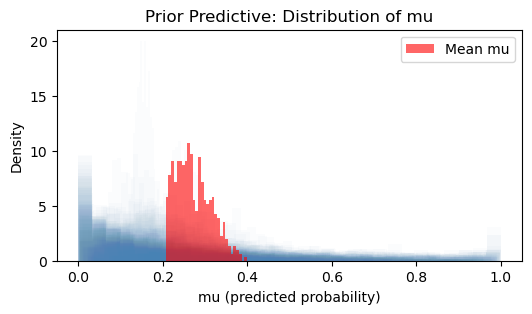

In [10]:
# --- Plot mu prior distribution ---
mu_samples = prior.prior["mu"].values.reshape(-1, X.shape[0])

plt.figure(figsize=(6, 3))
# --- Plot a random subset of 100 draw curves ---
for i in np.random.choice(mu_samples.shape[0], 100, replace=False):
    plt.hist(mu_samples[i], bins=30, alpha=0.02, color="steelblue", density=True)

# --- Plot mean across all draws ---
plt.hist(mu_samples.mean(axis=0), bins=30, alpha=0.6, color="red", density=True, label="Mean mu")
plt.xlabel("mu (predicted probability)")
plt.ylabel("Density")
plt.title("Prior Predictive: Distribution of mu")
plt.legend()
plt.show()

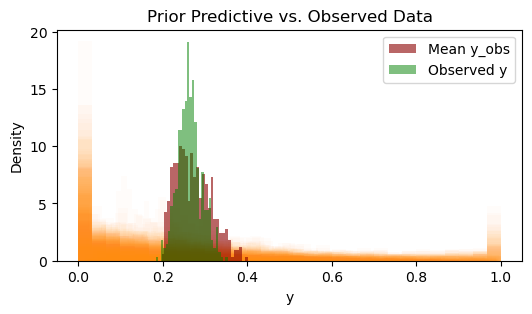

In [11]:
# --- Plot y_obs prior distribution ---
y_prior = prior.prior_predictive["y_obs"].values.reshape(-1, X.shape[0])

plt.figure(figsize=(6, 3))
for i in np.random.choice(y_prior.shape[0], 100, replace=False):
    plt.hist(y_prior[i], bins=30, alpha=0.02, color="darkorange", density=True)

plt.hist(y_prior.mean(axis=0), bins=30, alpha=0.6, color="darkred", density=True, label="Mean y_obs")

plt.hist(y, bins=30, alpha=0.5, color="green", density=True, label="Observed y")
plt.xlabel("y")
plt.ylabel("Density")
plt.title("Prior Predictive vs. Observed Data")
plt.legend()
plt.show()

In [12]:
print(f"Prior mu mean:        {mu_samples.mean():.3f}")
print(f"Prior y_obs mean:     {y_prior.mean():.3f}")
print(f"Observed y mean:      {y.mean():.3f}")

Prior mu mean:        0.272
Prior y_obs mean:     0.273
Observed y mean:      0.263


In [13]:
az.summary(trace, var_names=['alpha', 'betas', 'kappa'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.028,0.007,-1.042,-1.014,0.000,0.000,8945.0,4962.0,1.0
betas[Age2],-0.008,0.008,-0.022,0.006,0.000,0.000,8732.0,5392.0,1.0
betas[AVG],0.035,0.013,0.010,0.058,0.000,0.000,5660.0,5096.0,1.0
betas[xBA],0.030,0.013,0.006,0.053,0.000,0.000,5558.0,5439.0,1.0
kappa,191.572,10.390,171.250,210.218,0.109,0.117,9078.0,6471.0,1.0


In [14]:
# --- Test HDI coverage of 0 ---
for i, feature in enumerate(features):
    row = az.summary(trace, var_names=['betas']).iloc[i]
    contains_zero = row['hdi_3%'] < 0 < row['hdi_97%']
    zero_msg = " ⚠️ HDI contains zero" if contains_zero else ""
    print(f"{feature:12s}  mean={row['mean']:+.4f}  hdi=[{row['hdi_3%']:+.4f}, {row['hdi_97%']:+.4f}]{zero_msg}")

Age2          mean=-0.0080  hdi=[-0.0220, +0.0060] ⚠️ HDI contains zero
AVG           mean=+0.0350  hdi=[+0.0100, +0.0580]
xBA           mean=+0.0300  hdi=[+0.0060, +0.0530]


In [15]:
with model:
    pm.set_data({
        'X_data': X_2024,
        'y_data': np.full(len(df_2024), 0.111)
    })
    ppc_2024 = pm.sample_posterior_predictive(trace)

# --- Extract Predictions ---
pred_samples = ppc_2024.posterior_predictive['y_obs'].values.reshape(-1, len(df_2024))
print(f"pred_samples shape: {pred_samples.shape}")

hdi_vals = hdi(pred_samples, hdi_prob=0.94)
df_2024['predicted_AVG'] = pred_samples.mean(axis=0)
df_2024['pred_hdi_low'] = hdi_vals[:, 0]
df_2024['pred_hdi_high'] = hdi_vals[:, 1]

df_display = df_2024.dropna(subset=['AVG_next'])

df_display[['Name', 'AVG', 'xBA', 'predicted_AVG', 'AVG_next', 'pred_hdi_low', 'pred_hdi_high']]\
      .sort_values('predicted_AVG', ascending=False)\
      .head(20)

Sampling: [y_obs]


Output()

pred_samples shape: (8000, 129)


C:\Users\Andrew\AppData\Local\Temp\ipykernel_23120\1443150460.py:12: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_vals = hdi(pred_samples, hdi_prob=0.94)


,Name,AVG,xBA,predicted_AVG,AVG_next,pred_hdi_low,pred_hdi_high
100,Bobby Witt Jr.,0.332,0.309,0.295044,0.295,0.235388,0.358231
883,Vladimir Guerrero Jr.,0.323,0.317,0.294371,0.292,0.232633,0.354402
567,Luis Arraez,0.314,0.310,0.289492,0.292,0.230229,0.351928
4,Aaron Judge,0.322,0.305,0.287129,0.331,0.225777,0.348211
801,Shohei Ohtani,0.310,0.310,0.286663,0.282,0.225668,0.350283
490,Juan Soto,0.288,0.311,0.284033,0.263,0.227146,0.349317
917,Yainer Diaz,0.299,0.297,0.282611,0.256,0.223855,0.346383
596,Marcell Ozuna,0.302,0.283,0.276591,0.232,0.216603,0.338420
817,Steven Kwan,0.292,0.283,0.276427,0.272,0.219883,0.341833
519,Ketel Marte,0.292,0.289,0.276099,0.283,0.213654,0.336792


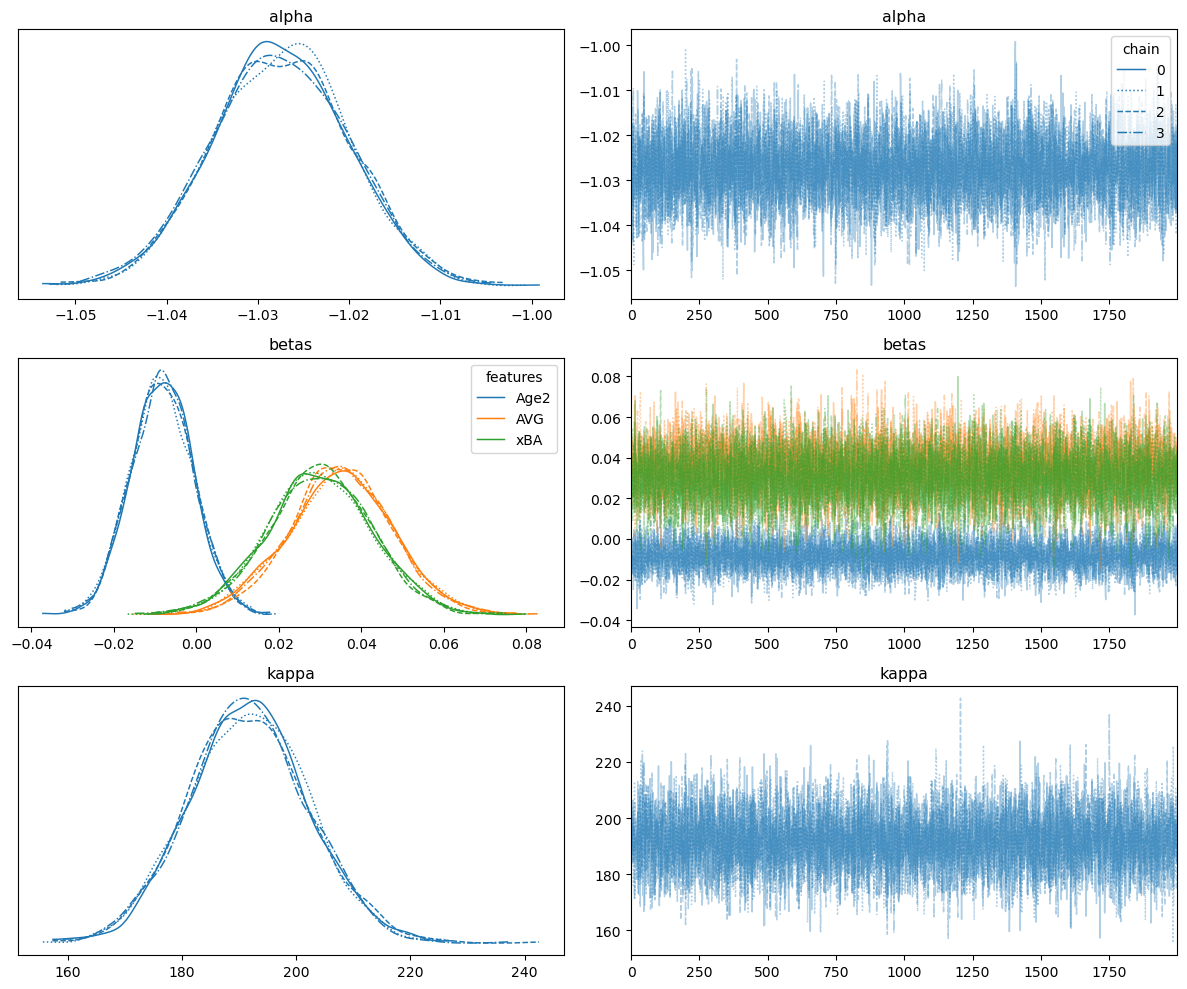

In [16]:
az.plot_trace(trace, var_names=['alpha', 'betas', 'kappa'], 
              figsize=(12, 10), legend=True)
plt.tight_layout()
plt.show()

In [17]:
# --- Drop players without a 2025 AVG ---
eval_df = df_2024.dropna(subset=['AVG_next']).copy()
print(f"Players with known 2025 AVG: {len(eval_df)} / {len(df_2024)}")

# --- RMSE ---
rmse = root_mean_squared_error(eval_df['AVG_next'], eval_df['predicted_AVG'])
print(f"RMSE: {rmse:.4f}") # on same scale as AVG: off by ~0.022 units on average

# --- Correlation ---
corr, pval = stats.pearsonr(eval_df['AVG_next'], eval_df['predicted_AVG'])
print(f"Pearson correlation: {corr:.4f}")
print(f"R^2: {corr**2:.4f}") # explains x% of variance
print(f"P-value: {pval:.4f}")

# --- Mean bias ---
bias = (eval_df['predicted_AVG'] - eval_df['AVG_next']).mean()
print(f"Mean bias: {bias:+.4f}") # whether the model over or under predicts (skew)

# --- Coverage ---
coverage = ((eval_df['AVG_next'] >= eval_df['pred_hdi_low']) & 
            (eval_df['AVG_next'] <= eval_df['pred_hdi_high'])).mean()
print(f"HDI coverage: {coverage:.1%}")

Players with known 2025 AVG: 88 / 129
RMSE: 0.0217
Pearson correlation: 0.4706
R^2: 0.2214
P-value: 0.0000
Mean bias: +0.0021
HDI coverage: 97.7%


Sampling: [y_obs]


Output()

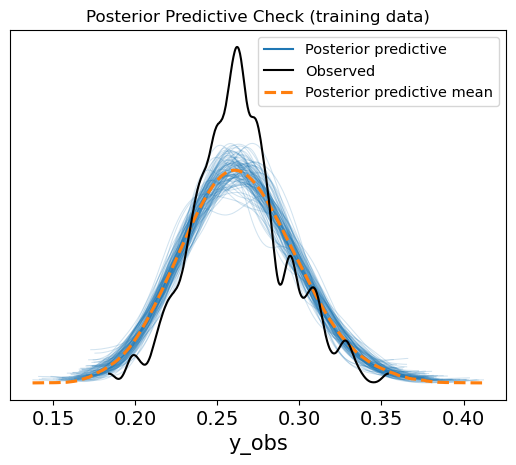

In [18]:
# --- Regenerate ppc on training data ---
with model:
    pm.set_data({'X_data': X, 'y_data': y})
    ppc_train = pm.sample_posterior_predictive(trace)

# --- Olot against real observed values ---
az.plot_ppc(ppc_train, num_pp_samples=100)
plt.title('Posterior Predictive Check (training data)')
plt.show()

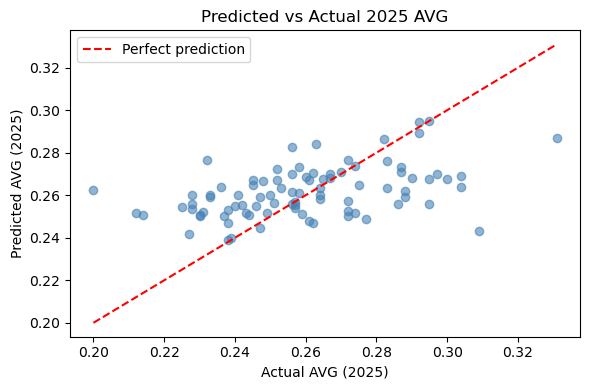

In [19]:
# --- Predicted vs Actual 2025 AVG ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(df_2024['AVG_next'], df_2024['predicted_AVG'], alpha=0.6, color='steelblue')

min_val = min(df_2024['AVG_next'].min(), df_2024['predicted_AVG'].min())
max_val = max(df_2024['AVG_next'].max(), df_2024['predicted_AVG'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')

ax.set_xlabel('Actual AVG (2025)')
ax.set_ylabel('Predicted AVG (2025)')
ax.set_title('Predicted vs Actual 2025 AVG')
ax.legend()

plt.tight_layout()
plt.show()

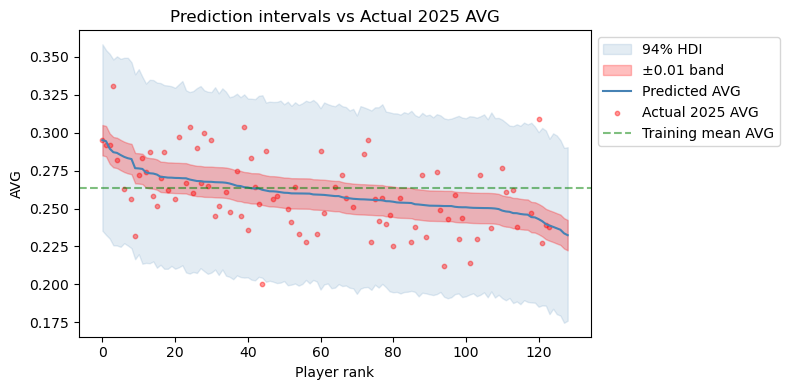

In [20]:
# --- Prediction intervals vs Actual 2025 AVG ---
fig, ax = plt.subplots(figsize=(8, 4))

df_sorted = df_2024.sort_values('predicted_AVG', ascending=False).reset_index(drop=True)

ax.fill_between(
    range(len(df_sorted)),
    df_sorted['pred_hdi_low'],
    df_sorted['pred_hdi_high'],
    alpha=0.15, color='steelblue', label='94% HDI'
)

ax.fill_between(
    range(len(df_sorted)),
    df_sorted['predicted_AVG'] - 0.01,
    df_sorted['predicted_AVG'] + 0.01,
    alpha=0.25, color='red', label='±0.01 band'
)

ax.plot(range(len(df_sorted)), df_sorted['predicted_AVG'],
        color='steelblue', linewidth=1.5, label='Predicted AVG')
ax.scatter(range(len(df_sorted)), df_sorted['AVG_next'],
           color='red', s=10, alpha=0.4, label='Actual 2025 AVG')

ax.axhline(y.mean(), color='green', linestyle='--', alpha=0.5, label='Training mean AVG')

ax.set_xlabel('Player rank')
ax.set_ylabel('AVG')
ax.set_title('Prediction intervals vs Actual 2025 AVG')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [21]:
# --- Grading --- 
n_total = len(df_2024)

for band in [0.01, 0.025, 0.05]:
    n_within = ((df_2024['AVG_next'] >= df_2024['predicted_AVG'] - band) &
                (df_2024['AVG_next'] <= df_2024['predicted_AVG'] + band)).sum()
    print(f"{n_within}/{n_total} predictions within ±{band} ({n_within/n_total:.1%})")

34/129 predictions within ±0.01 (26.4%)
64/129 predictions within ±0.025 (49.6%)
86/129 predictions within ±0.05 (66.7%)


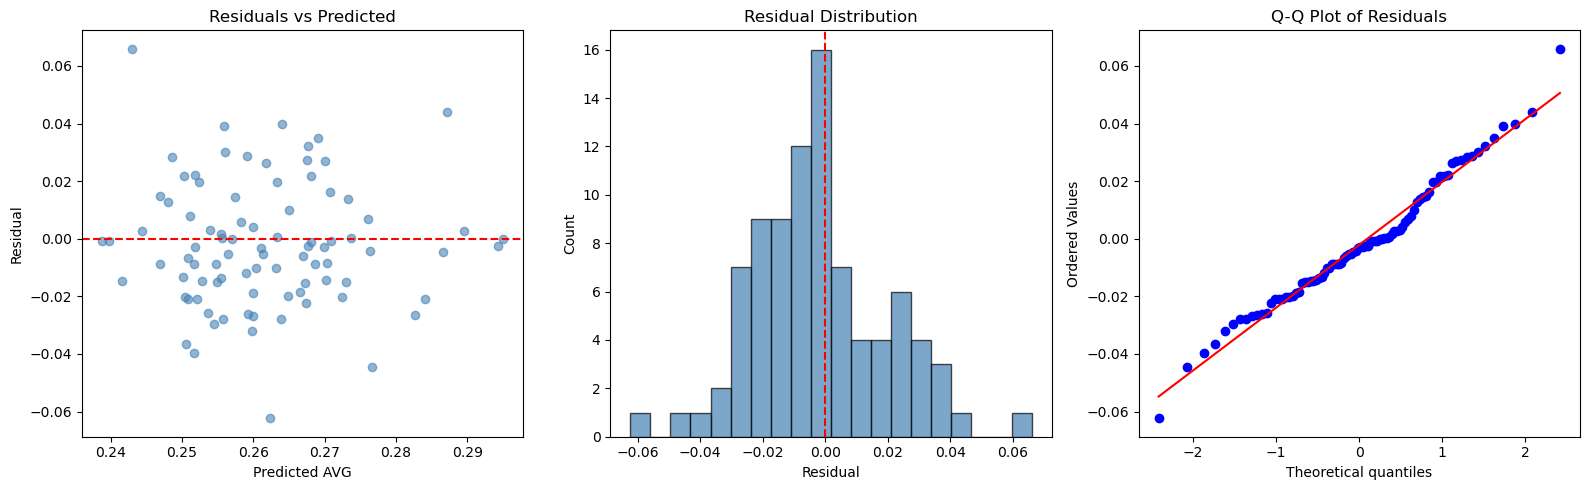

In [22]:
# --- Residual Analysis ---
residuals = eval_df['AVG_next'].values - eval_df['predicted_AVG'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Residuals vs Predicted ---
ax = axes[0]
ax.scatter(eval_df['predicted_AVG'], residuals, alpha=0.6, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted AVG')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted')

# --- Residuals Histogram ---
ax = axes[1]
ax.hist(residuals, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

# --- Q-Q Plot ---
ax = axes[2]
stats.probplot(residuals, plot=ax)
ax.set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [23]:
with model:
    pm.set_data({
        'X_data': X_2024,
        'y_data': np.full(len(df_2024), 0.111)
    })
    ppc_2024 = pm.sample_posterior_predictive(trace)

# extract predictions
pred_samples = ppc_2024.posterior_predictive['y_obs'].values.reshape(-1, len(df_2024))
print(f"pred_samples shape: {pred_samples.shape}")

hdi_vals = hdi(pred_samples, hdi_prob=0.94)
df_2024['predicted_AVG'] = pred_samples.mean(axis=0)
df_2024['pred_hdi_low'] = hdi_vals[:, 0]
df_2024['pred_hdi_high'] = hdi_vals[:, 1]

df_2024[['Name', 'AVG', 'xBA', 'predicted_AVG', 'AVG_next', 'pred_hdi_low', 'pred_hdi_high']]\
      .sort_values('predicted_AVG', ascending=False)\
      .head(20)

Sampling: [y_obs]


Output()

pred_samples shape: (8000, 129)


C:\Users\Andrew\AppData\Local\Temp\ipykernel_23120\3062125380.py:12: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_vals = hdi(pred_samples, hdi_prob=0.94)


,Name,AVG,xBA,predicted_AVG,AVG_next,pred_hdi_low,pred_hdi_high
100,Bobby Witt Jr.,0.332,0.309,0.295116,0.295,0.233812,0.358216
883,Vladimir Guerrero Jr.,0.323,0.317,0.294134,0.292,0.233019,0.359697
567,Luis Arraez,0.314,0.310,0.288896,0.292,0.228977,0.352563
801,Shohei Ohtani,0.310,0.310,0.286867,0.282,0.225534,0.347785
4,Aaron Judge,0.322,0.305,0.286828,0.331,0.227629,0.350656
936,Yordan Alvarez,0.308,0.300,0.284701,NaN,0.223983,0.346036
490,Juan Soto,0.288,0.311,0.283507,0.263,0.222953,0.345137
364,Jackson Merrill,0.292,0.300,0.283297,NaN,0.222905,0.344132
917,Yainer Diaz,0.299,0.297,0.282173,0.256,0.223451,0.344323
519,Ketel Marte,0.292,0.289,0.276249,0.283,0.211379,0.335151


In [24]:
# --- Exploring AVG percentiles ---
p50 = np.percentile(df["AVG"], 50)
p75 = np.percentile(df["AVG"], 75)
p90 = np.percentile(df["AVG"], 90)
p95 = np.percentile(df["AVG"], 95)
p99 = np.percentile(df["AVG"], 99)

print(f"Median AVG):        {p50:.3f}")
print(f"75th percentile:    {p75:.3f}")
print(f"90th percentile:    {p90:.3f}")
print(f"99th percentile:    {p99:.3f}")

Median AVG):        0.261
75th percentile:    0.279
90th percentile:    0.297
99th percentile:    0.329
